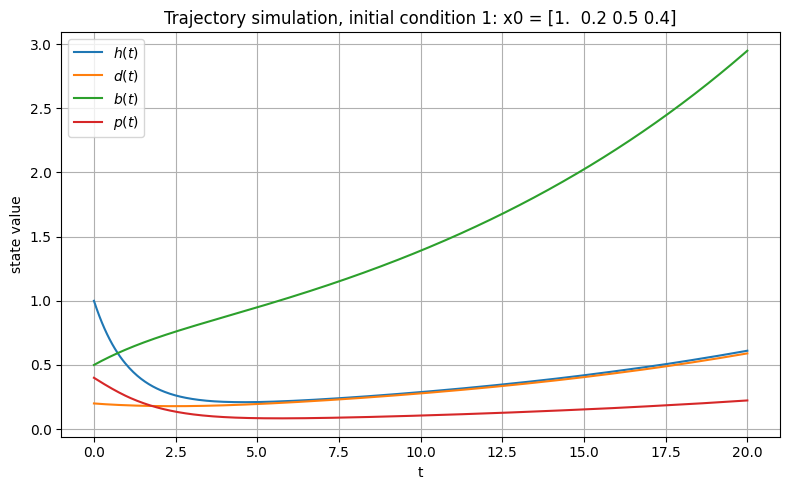

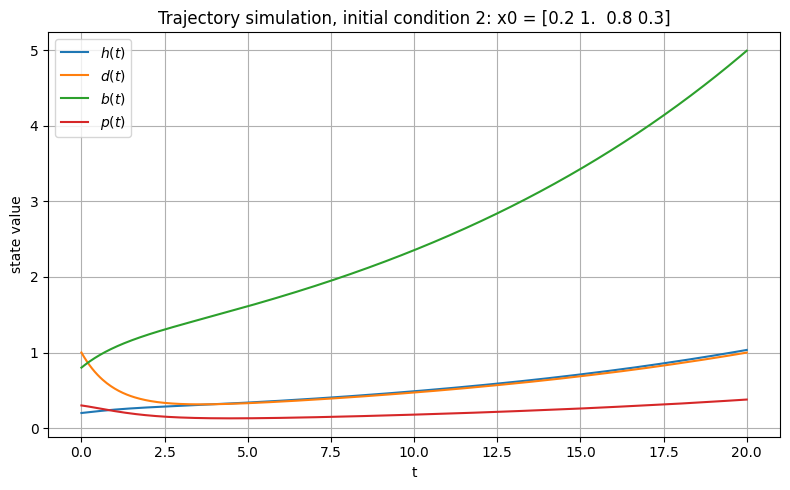

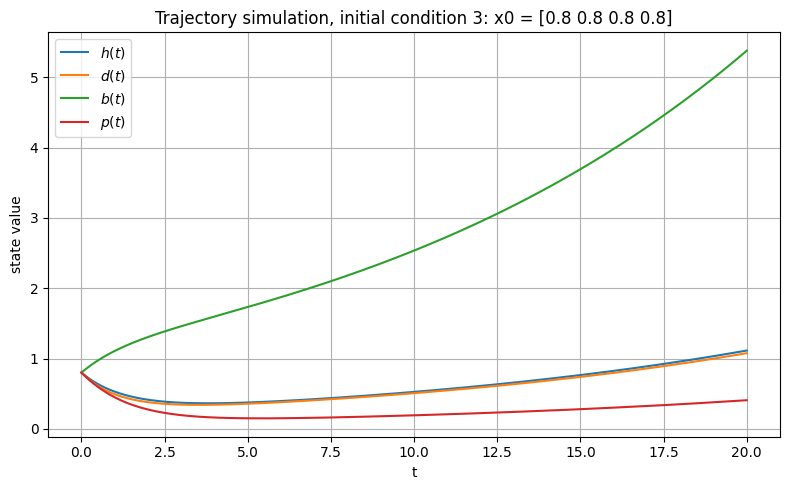

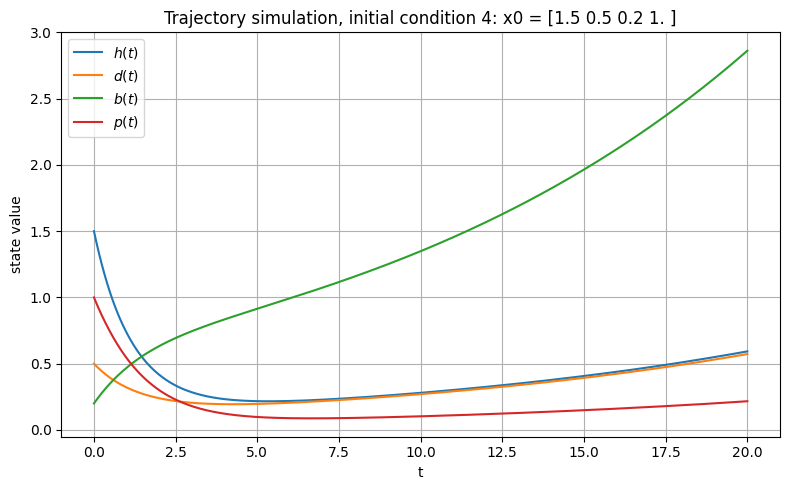

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters that does not decay to zero
#lambda_h = 0.4
#lambda_d = 0.4
#lambda_b = 0.4
#lambda_p = 0.4

# Parameters that decay to zero
lambda_h = 1
lambda_d = 1
lambda_b = 0
lambda_p = 1.0

# lambda_h = 1.2
# lambda_d = 1.1
# lambda_b = 1.3
# lambda_p = 1.0

alpha_hb = 0.2
alpha_hp = 0.3
alpha_db = 0.2
alpha_dp = 0.2
alpha_bd = 0.3
alpha_bp = 0.2
alpha_pd = 0.2
alpha_ph = 0.2

# System matrix
A = np.array([
    [-lambda_h, 0.0,       alpha_hb, alpha_hp],
    [0.0,       -lambda_d, alpha_db, alpha_dp],
    [0.0,       alpha_bd, -lambda_b, alpha_bp],
    [alpha_ph,  alpha_pd,  0.0,      -lambda_p]
], dtype=float)

def rhs(t, x):
    return A @ x

# Time grid
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Several initial conditions
initial_conditions = [
    np.array([1.0, 0.2, 0.5, 0.4]),
    np.array([0.2, 1.0, 0.8, 0.3]),
    np.array([0.8, 0.8, 0.8, 0.8]),
    np.array([1.5, 0.5, 0.2, 1.0]),
]
labels = [r"$h(t)$", r"$d(t)$", r"$b(t)$", r"$p(t)$"]

for i, x0 in enumerate(initial_conditions, start=1):
    sol = solve_ivp(rhs, t_span, x0, t_eval=t_eval)

    plt.figure(figsize=(8, 5))
    for j in range(4):
        plt.plot(sol.t, sol.y[j], label=labels[j])
    plt.title(f"Trajectory simulation, initial condition {i}: x0 = {x0}")
    plt.xlabel("t")
    plt.ylabel("state value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

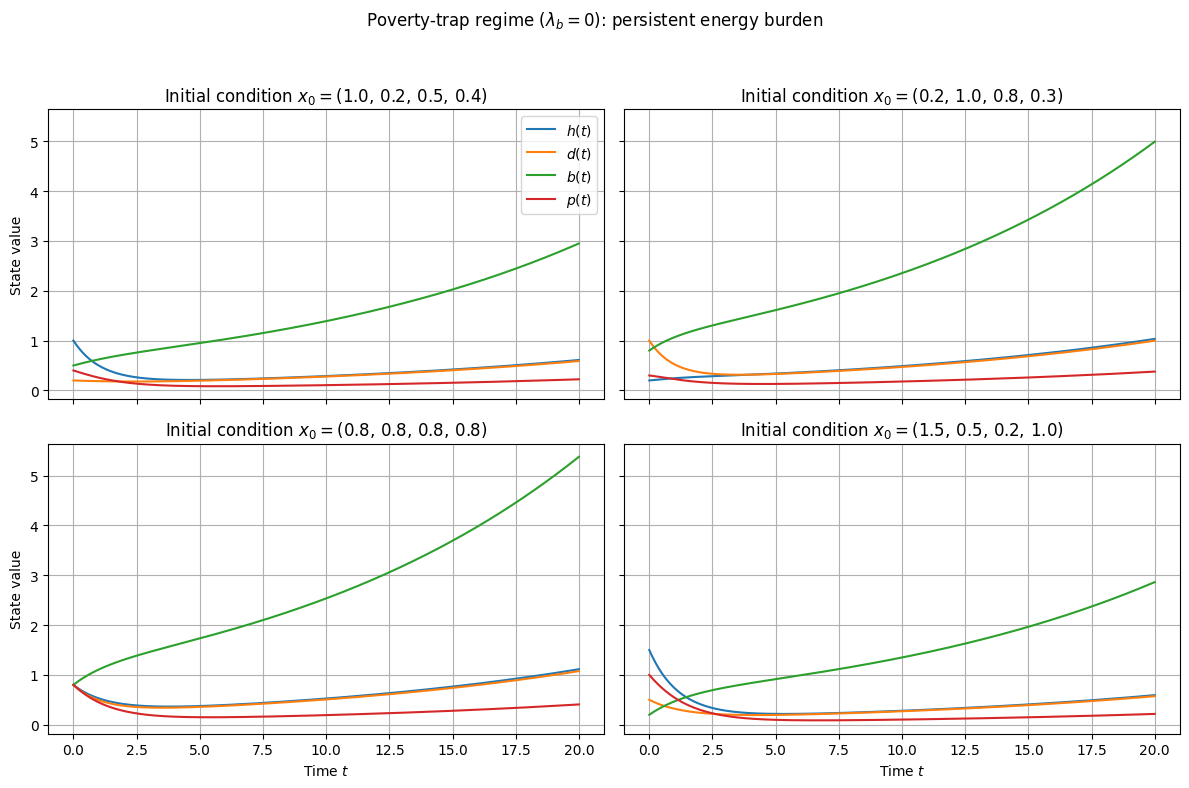

Eigenvalues (poverty-trap regime):
[ 0.07518322 -1.315145   -0.74609031 -1.01394791]


In [ ]:
# --- Unstable (poverty-trap) regime ---
lambda_h = 1.0
lambda_d = 1.0
lambda_b = 0.0   # NO direct damping of energy burden
lambda_p = 1.0

A = np.array([
    [-lambda_h, 0.0,        alpha_hb, alpha_hp],
    [0.0,       -lambda_d, alpha_db, alpha_dp],
    [0.0,        alpha_bd, -lambda_b, alpha_bp],
    [alpha_ph,   alpha_pd, 0.0,      -lambda_p]
])

def rhs(t, x):
    return A @ x

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, x0 in zip(axes, initial_conditions):
    sol = solve_ivp(rhs, t_span, x0, t_eval=t_eval)
    for i in range(4):
        ax.plot(sol.t, sol.y[i], label=labels[i])

    x0_str = ",\\,".join([f"{v:.1f}" for v in x0])
    ax.set_title(rf"Initial condition $x_0=({x0_str})$")

    ax.grid(True)

axes[0].legend()
for ax in axes[2:]:
    ax.set_xlabel("Time $t$")
for ax in axes[::2]:
    ax.set_ylabel("State value")

plt.suptitle("Poverty-trap regime ($\\lambda_b = 0$): persistent energy burden")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("unstable_regime_trajectories.png", dpi=300)
plt.show()

# Eigenvalues
print("Eigenvalues (poverty-trap regime):")
print(np.linalg.eigvals(A))

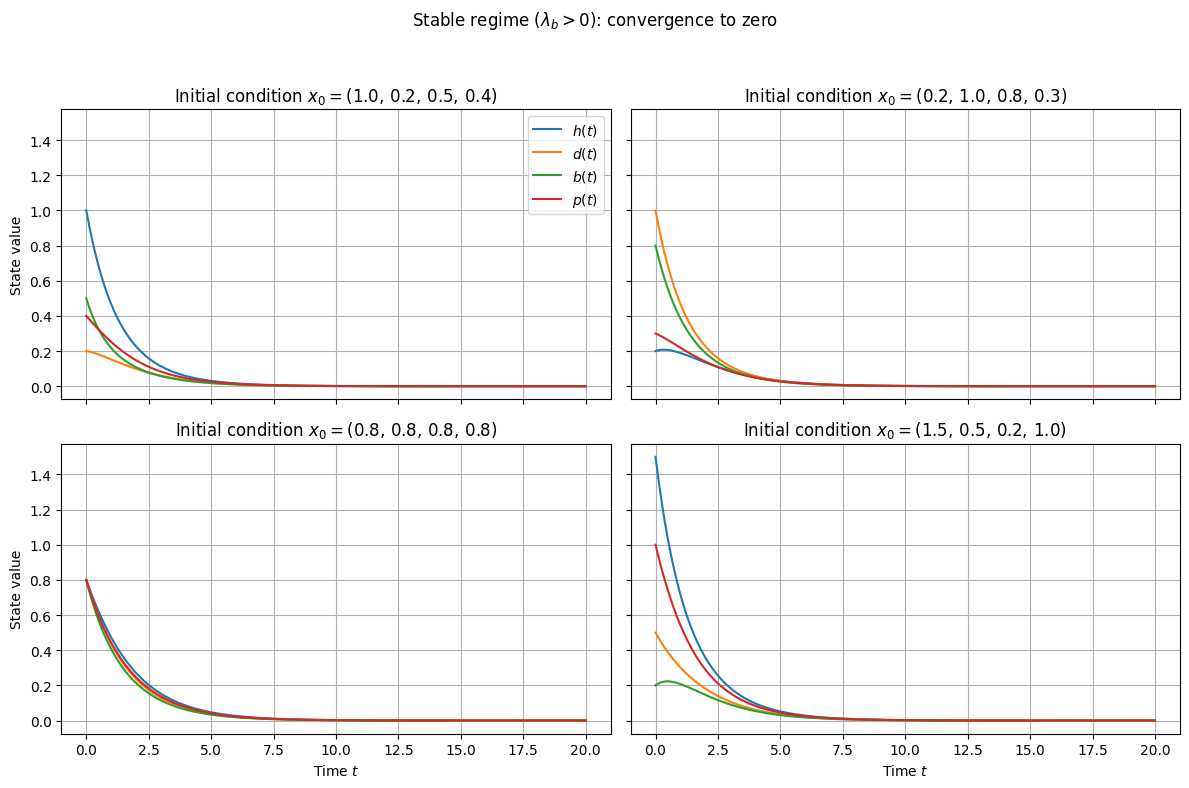

Eigenvalues (stable regime):
[-0.5978969 +0.j         -0.97039623+0.j         -1.31585343+0.03232702j
 -1.31585343-0.03232702j]


In [ ]:
# --- Stable regime ---
lambda_h = 1.0
lambda_d = 1.0
lambda_b = 1.2   # DIRECT damping of energy burden
lambda_p = 1.0

A = np.array([
    [-lambda_h, 0.0,        alpha_hb, alpha_hp],
    [0.0,       -lambda_d, alpha_db, alpha_dp],
    [0.0,        alpha_bd, -lambda_b, alpha_bp],
    [alpha_ph,   alpha_pd, 0.0,      -lambda_p]
])

def rhs(t, x):
    return A @ x

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, x0 in zip(axes, initial_conditions):
    sol = solve_ivp(rhs, t_span, x0, t_eval=t_eval)
    for i in range(4):
        ax.plot(sol.t, sol.y[i], label=labels[i])

    x0_str = ",\\,".join([f"{v:.1f}" for v in x0])
    ax.set_title(rf"Initial condition $x_0=({x0_str})$")

    ax.grid(True)

axes[0].legend()
for ax in axes[2:]:
    ax.set_xlabel("Time $t$")
for ax in axes[::2]:
    ax.set_ylabel("State value")

plt.suptitle("Stable regime ($\\lambda_b > 0$): convergence to zero")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("stable_regime_trajectories.png", dpi=300)
plt.show()

# Eigenvalues
print("Eigenvalues (stable regime):")
print(np.linalg.eigvals(A))